# Gestion de Portefeuille - TP1

William Bourque (XXX)

Robin Dubillot (XXX)

Philippe Mondor (11303766)

Frederic Pelletier (11359258)

## Partie A

**Librairies**


In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.correlation_tools import cov_nearest
from scipy.optimize import minimize
from partieA import *
from partieB import *
from scipy.special import beta as beta_fn, betainc

**Données**

In [19]:
data = load_data('../data/48_Industry_Portfolios.csv')
industries = ['Books', 'Soda', 'FabPr', 'Steel', 'Aero']

data_last_five_years = extract_last_five_years(data, industries)
sigma = compute_sigma(data_last_five_years)

### Question 1
Construire le graphique de « mean-variance locus » (sans l’actif sans risque) de ces 5
industries. Présentez et discutez ces résultats en spécifiant chacun de 5 industries dans le
graphique.

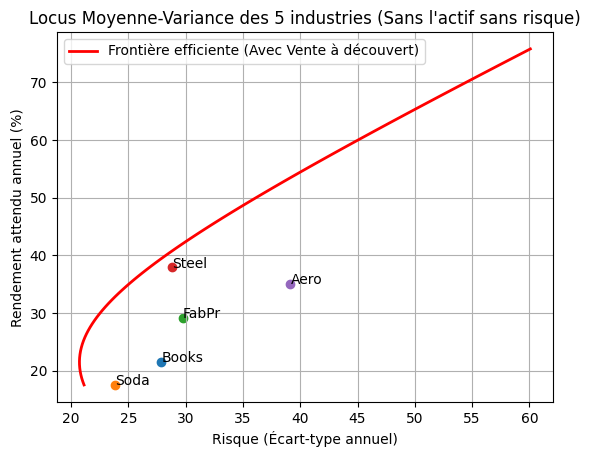

In [20]:
weights,variances,returns,mu = efficient_frontier_closed_form(data_last_five_years,sigma,annualize=True)
asset_sigmas = np.sqrt(np.diag(sigma.values * 12))
for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)

plt.plot(np.sqrt(variances), returns, color='red', linewidth=2, label='Frontière efficiente (Avec Vente à découvert)')
plt.legend()
plt.xlabel('Risque (Écart-type annuel)')
plt.ylabel('Rendement attendu annuel (%)')
plt.title("Locus Moyenne-Variance des 5 industries (Sans l'actif sans risque)")
plt.grid(True)
plt.show()

### Question 2
Construire le graphique de « mean-variance locus » (avec l’actif sans risque) de ces 5
industries. Spécifiez chaque industrie dans le graphique. Présentez et discutez ces résultats.
Expliquez comment le « mean-variance locus » a changé avec l’actif sans risque. 

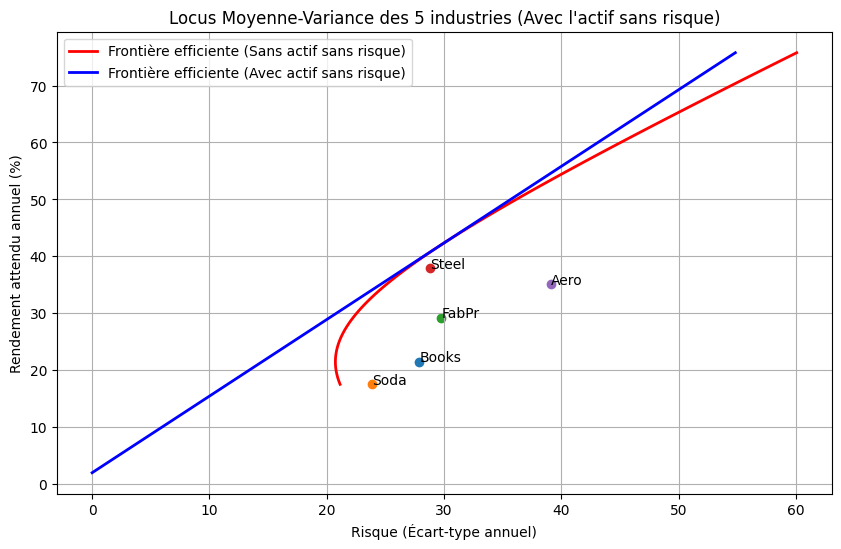

In [21]:
R = 2  # 2% risk-free rate
rf_res = mean_variance_locus_with_rfr_notes(
    data_last_five_years, sigma, n_ptf=250, R=R, annualize=True
)
plt.figure(figsize=(10, 6))
for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)
plt.plot(np.sqrt(variances), returns, color='red', linewidth=2, label='Frontière efficiente (Sans actif sans risque)')
plt.plot(np.sqrt(rf_res['variances']), rf_res['target_returns'], color='blue', linewidth=2, label='Frontière efficiente (Avec actif sans risque)')
plt.xlabel('Risque (Écart-type annuel)')
plt.ylabel('Rendement attendu annuel (%)')
plt.title("Locus Moyenne-Variance des 5 industries (Avec l'actif sans risque)")
plt.legend()
plt.grid(True)
plt.show()

### Question 3
Décrire le portefeuille tangent et ses caractéristiques comme sa moyenne et variance et les
poids de chaque industrie dans ce portefeuille tangent. Vérifiez numériquement que le
portefeuille tangent est le portefeuille qui maximise le ratio de Sharpe. Présentez et discutez
ces résultats.


QUESTION 3 — Portefeuille tangent (risky-only) et ratio de Sharpe
Taux sans risque R (annuel, en %): 2.000000
Somme des poids (doit être 1): 1.0000000000
Moyenne du portefeuille tangent μ_tan (%/an): 41.953440
Variance du portefeuille tangent Var_tan: 882.439901
Écart-type du portefeuille tangent σ_tan (%/an): 29.705890
Sharpe_tan = (μ_tan - R)/σ_tan: 1.344967

Poids par industrie (w_tan):
Books   -0.623010
Soda    +0.231957
FabPr   +0.164906
Steel   +1.236871
Aero    -0.010724

Vérification numérique (frontière efficiente risquée):
Sharpe maximum sur la frontière (discrétisée): 1.344936
Différence |Sharpe_max - Sharpe_tan|: 3.074387e-05

Poids du portefeuille (frontière) au Sharpe max:
Books   -0.633617
Soda    +0.227027
FabPr   +0.163749
Steel   +1.251776
Aero    -0.008935


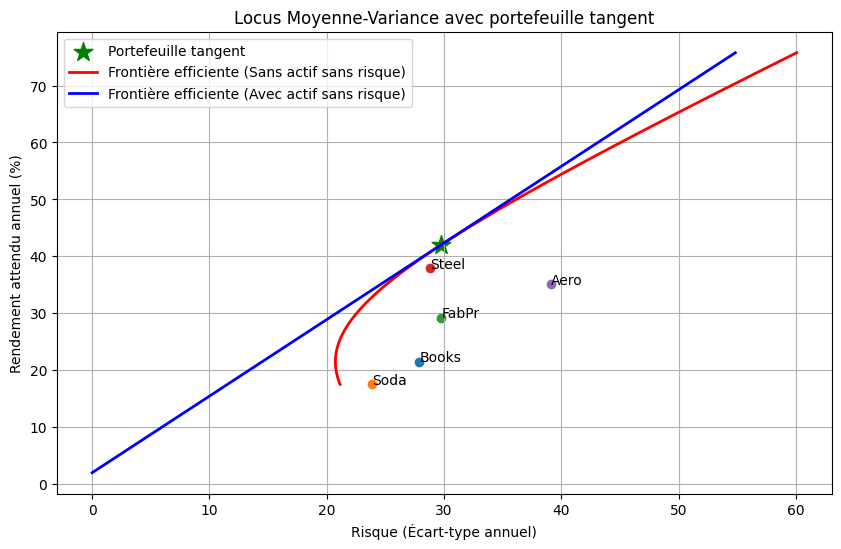

In [22]:
w_tan, mu_tan, var_tan, sig_tan, sharpe_tan = tangency_portfolio(data_last_five_years, sigma, R=R, annualize=True)

sep = "=" * 72
print(f"\n{sep}")
print("QUESTION 3 — Portefeuille tangent (risky-only) et ratio de Sharpe")
print(sep)
print(f"Taux sans risque R (annuel, en %): {R:.6f}")
print(f"Somme des poids (doit être 1): {w_tan.sum():.10f}")
print(f"Moyenne du portefeuille tangent μ_tan (%/an): {mu_tan:.6f}")
print(f"Variance du portefeuille tangent Var_tan: {var_tan:.6f}")
print(f"Écart-type du portefeuille tangent σ_tan (%/an): {sig_tan:.6f}")
print(f"Sharpe_tan = (μ_tan - R)/σ_tan: {sharpe_tan:.6f}")

print("\nPoids par industrie (w_tan):")
print(w_tan.to_string(float_format=lambda x: f"{x:+.6f}"))

sharpe_max, idx_max = verify_tangency_max_sharpe(returns, variances, R=R)
print("\nVérification numérique (frontière efficiente risquée):")
print(f"Sharpe maximum sur la frontière (discrétisée): {sharpe_max:.6f}")
print(f"Différence |Sharpe_max - Sharpe_tan|: {abs(sharpe_max - sharpe_tan):.6e}")

w_frontier_max = weights.iloc[idx_max]
w_frontier_max = w_frontier_max / w_frontier_max.sum()
print("\nPoids du portefeuille (frontière) au Sharpe max:")
print(w_frontier_max.to_string(float_format=lambda x: f"{x:+.6f}"))
print(sep)


plt.figure(figsize=(10, 6))
for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)
plt.scatter(sig_tan, mu_tan, color='green', marker='*', s=200, label='Portefeuille tangent')
plt.plot(np.sqrt(variances), returns, color='red', linewidth=2, label='Frontière efficiente (Sans actif sans risque)')
plt.plot(np.sqrt(rf_res['variances']), rf_res['target_returns'], color='blue', linewidth=2, label='Frontière efficiente (Avec actif sans risque)')
plt.xlabel('Risque (Écart-type annuel)')
plt.ylabel('Rendement attendu annuel (%)')
plt.title("Locus Moyenne-Variance avec portefeuille tangent")
plt.legend()
plt.grid(True)
plt.show()

### Question 4
Construire le graphique de « mean-variance locus » (sans l’actif sans risque) avec les
contraintes de vente à découverte sur chaque industrie. Présentez et discutez ces résultats
en spécifiant chaque industrie dans le graphique. 

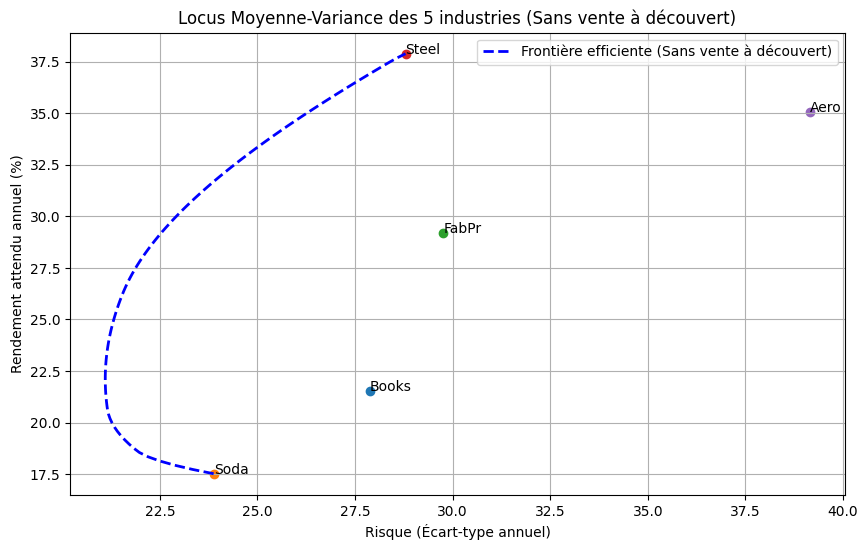

In [23]:
weights_num,variances_num,returns_num,mu_num = efficient_frontier_numerical(data_last_five_years,sigma,annualize=True,short_selling=False)

fig = plt.figure(figsize=(10, 6))
for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)


plt.plot(np.sqrt(variances_num), returns_num, color='blue', linewidth=2,linestyle='--', label='Frontière efficiente (Sans vente à découvert)')
plt.xlabel('Risque (Écart-type annuel)')
plt.ylabel('Rendement attendu annuel (%)')
plt.title("Locus Moyenne-Variance des 5 industries (Sans vente à découvert)")
plt.legend()
plt.grid(True)
plt.show()

### Question 5

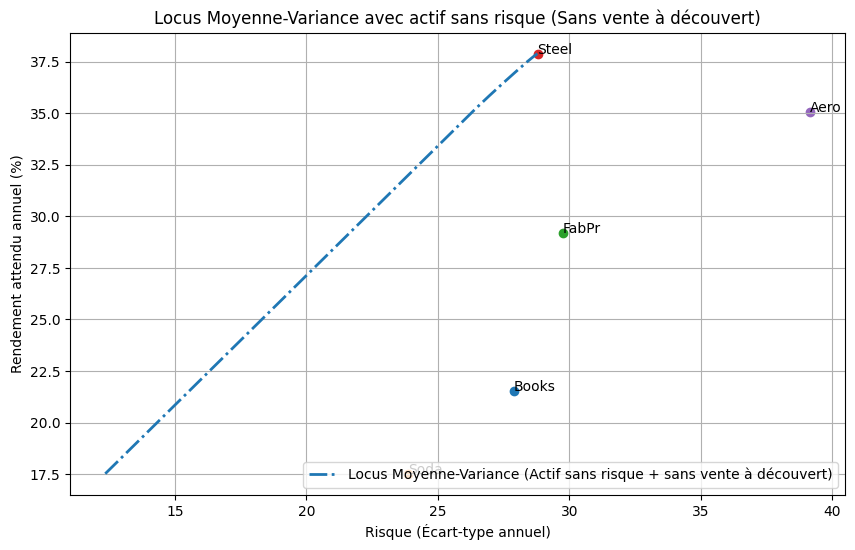

In [24]:
R = 2
weights_noshort, variances_noshort, rets_noshort, mu_noshort = efficient_frontier_with_rfr_noshort(
data_last_five_years, sigma, R, n_ptf=250, annualize=True
)

sig_q5 = np.sqrt(np.array(variances_noshort))
mu_q5 = np.array(rets_noshort)[:len(sig_q5)]

plt.figure(figsize=(10, 6))
plt.plot(sig_q5, mu_q5, linestyle='-.', linewidth=2, label='Locus Moyenne-Variance (Actif sans risque + sans vente à découvert)')

for i, industry in enumerate(industries):
    plt.scatter(asset_sigmas[i], mu[i])
    plt.text(asset_sigmas[i], mu[i], industry)

plt.xlabel('Risque (Écart-type annuel)')
plt.ylabel('Rendement attendu annuel (%)')
plt.title("Locus Moyenne-Variance avec actif sans risque (Sans vente à découvert)")
plt.legend()
plt.grid(True)
plt.show()

### Question 6

In [25]:
R = 2
mu_assets = data_last_five_years.mean().values * 12
Sigma_assets = sigma.values * 12

w_star, mu_p, var_p, sharpe_p = tangency_portfolio_noshort(mu_assets, Sigma_assets, R)

print("\n================ Q6: Tangency (Rf=2, no-short) ================")
print("Poids du portefeuille tangent (long-only):")
for name, w in zip(industries, w_star):
    print(f"  {name}: {w:.4f}")
print(f"Moyenne (mu_p): {mu_p:.6f}")
print(f"Variance (var_p): {var_p:.6f}")
print(f"Ecart-type (sigma_p): {np.sqrt(var_p):.6f}")
print(f"Sharpe (mu_p - R)/sigma_p: {sharpe_p:.6f}")

max_sharpe_rand, w_best_rand = verify_max_sharpe_random(mu_assets, Sigma_assets, R, n_random=20000, seed=0)
print(f"Max Sharpe (random long-only, n=20000): {max_sharpe_rand:.6f}")
print(f"Diff (tangency - random max): {sharpe_p - max_sharpe_rand:.6e}")


================ Q6: Tangency (Rf=2, no-short) ================
Poids du portefeuille tangent (long-only):
  Books: 0.0000
  Soda: 0.1149
  FabPr: 0.0877
  Steel: 0.7973
  Aero: 0.0000
Moyenne (mu_p): 34.781222
Variance (var_p): 680.612900
Ecart-type (sigma_p): 26.088559
Sharpe (mu_p - R)/sigma_p: 1.256536
Max Sharpe (random long-only, n=20000): 1.254130
Diff (tangency - random max): 2.405929e-03


# Partie B

### Question 1


PARTIE B — QUESTION 1 : BOOTSTRAP (incertitude d'estimation)
Nombre de réplications bootstrap : 200
Industries : Books, Soda, FabPr, Steel, Aero
Taux sans risque utilisé (unique) : R = 2

--------------------------------------------------------------------------------------
Q1 — Frontière efficiente (sans actif sans risque, short-selling autorisé)
Point médian de frontière (index ~50%) — Bootstrap vs Partie A :
  σ_boot (p50) = 30.2196 | 5%-95% = [21.9989, 51.2781] | σ_A = 33.6684
  μ_boot (p50) = 48.6153 | 5%-95% = [23.3576, 79.7107] | μ_A = 47.0132
Incertitude (bootstrap) :
  Largeur bande 90% sur σ : 29.2791
  Largeur bande 90% sur μ : 56.3531
  Écart (p50_boot - A) sur σ : -3.4488
  Écart (p50_boot - A) sur μ : +1.6021

--------------------------------------------------------------------------------------
Q2 — Frontière efficiente (avec actif sans risque, short-selling autorisé)
Point médian de locus (index ~50%) — Bootstrap vs Partie A :
  σ_boot (p50) = 24.5164 | 5%-95% = [15.44

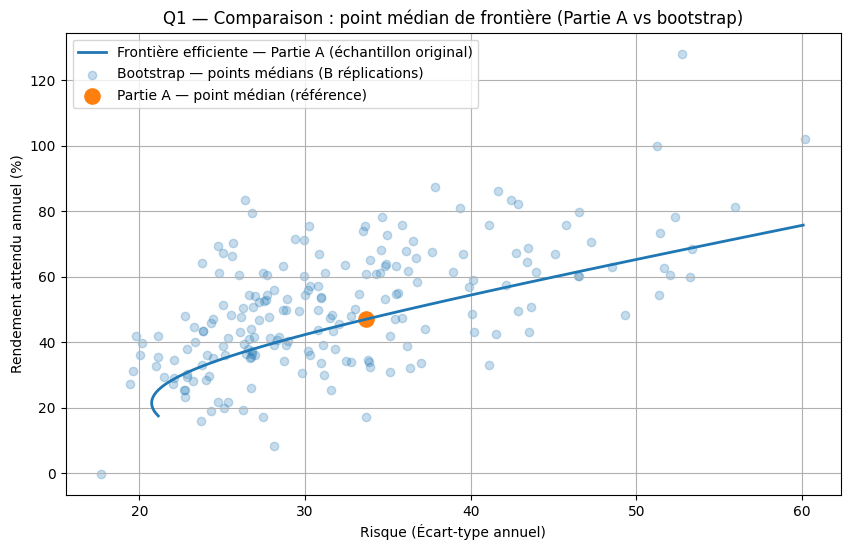

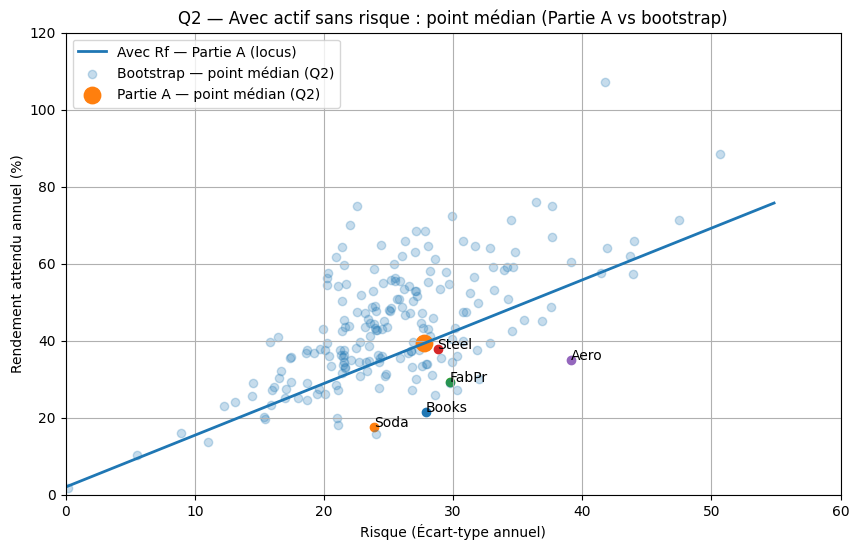

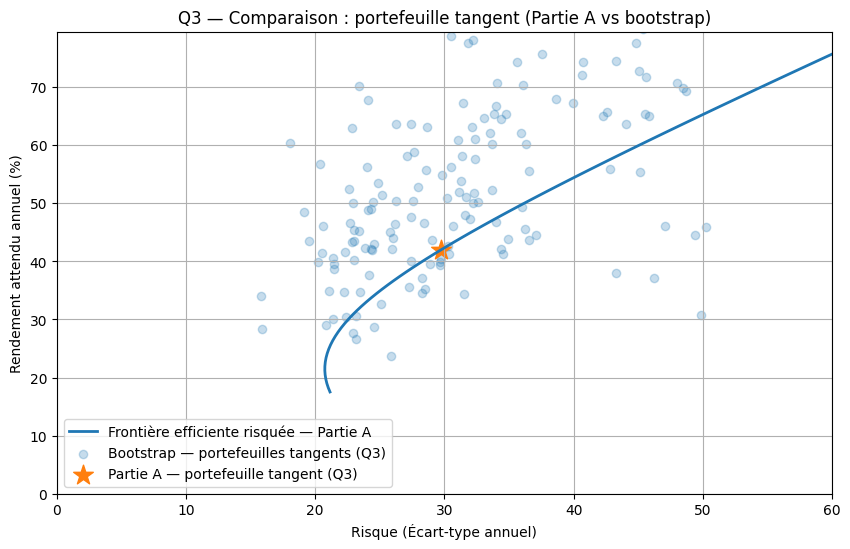

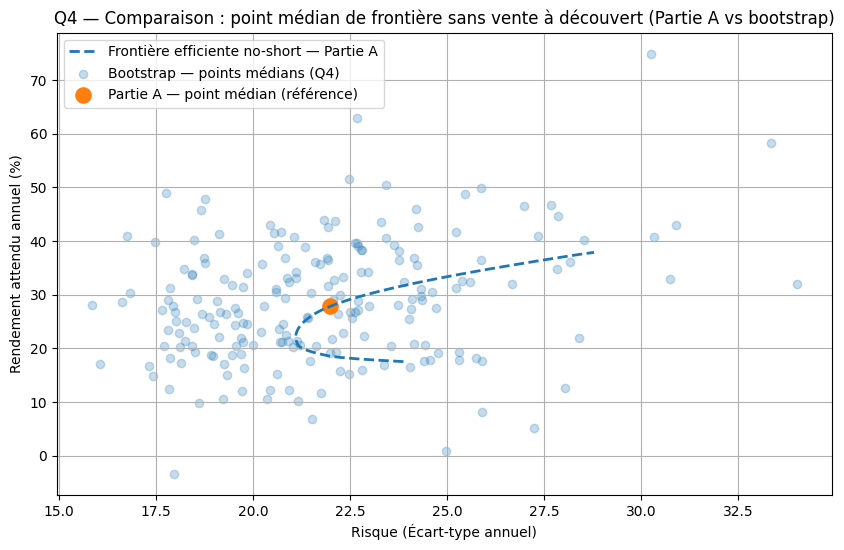

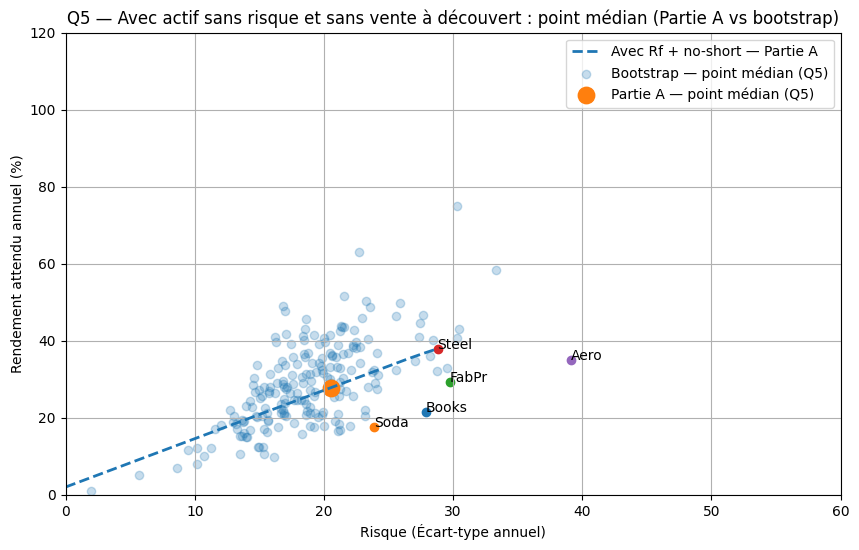

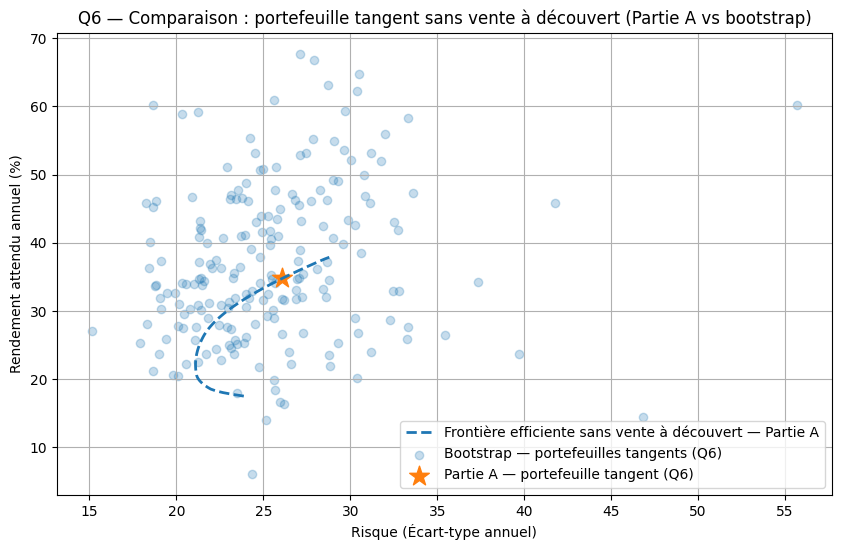

In [26]:
# =========================
# PARTIE B — QUESTION 1 : BOOTSTRAP
# =========================

# Paramètres
B_rep = 200         # (tu peux mettre 200 pour tester plus vite)
n_ptf = 80           # résolution de la frontière
R = 2

res_b1 = b1_bootstrap_1000(
    returns_5=data_last_five_years,
    industries=industries,
    B=B_rep,
    annualize=True,
    R=R,
    n_ptf=n_ptf,
    seed=0
)

b1_print_sections_fr(res_b1)

b1_plot_2_graphiques(res_b1)


### Question 2

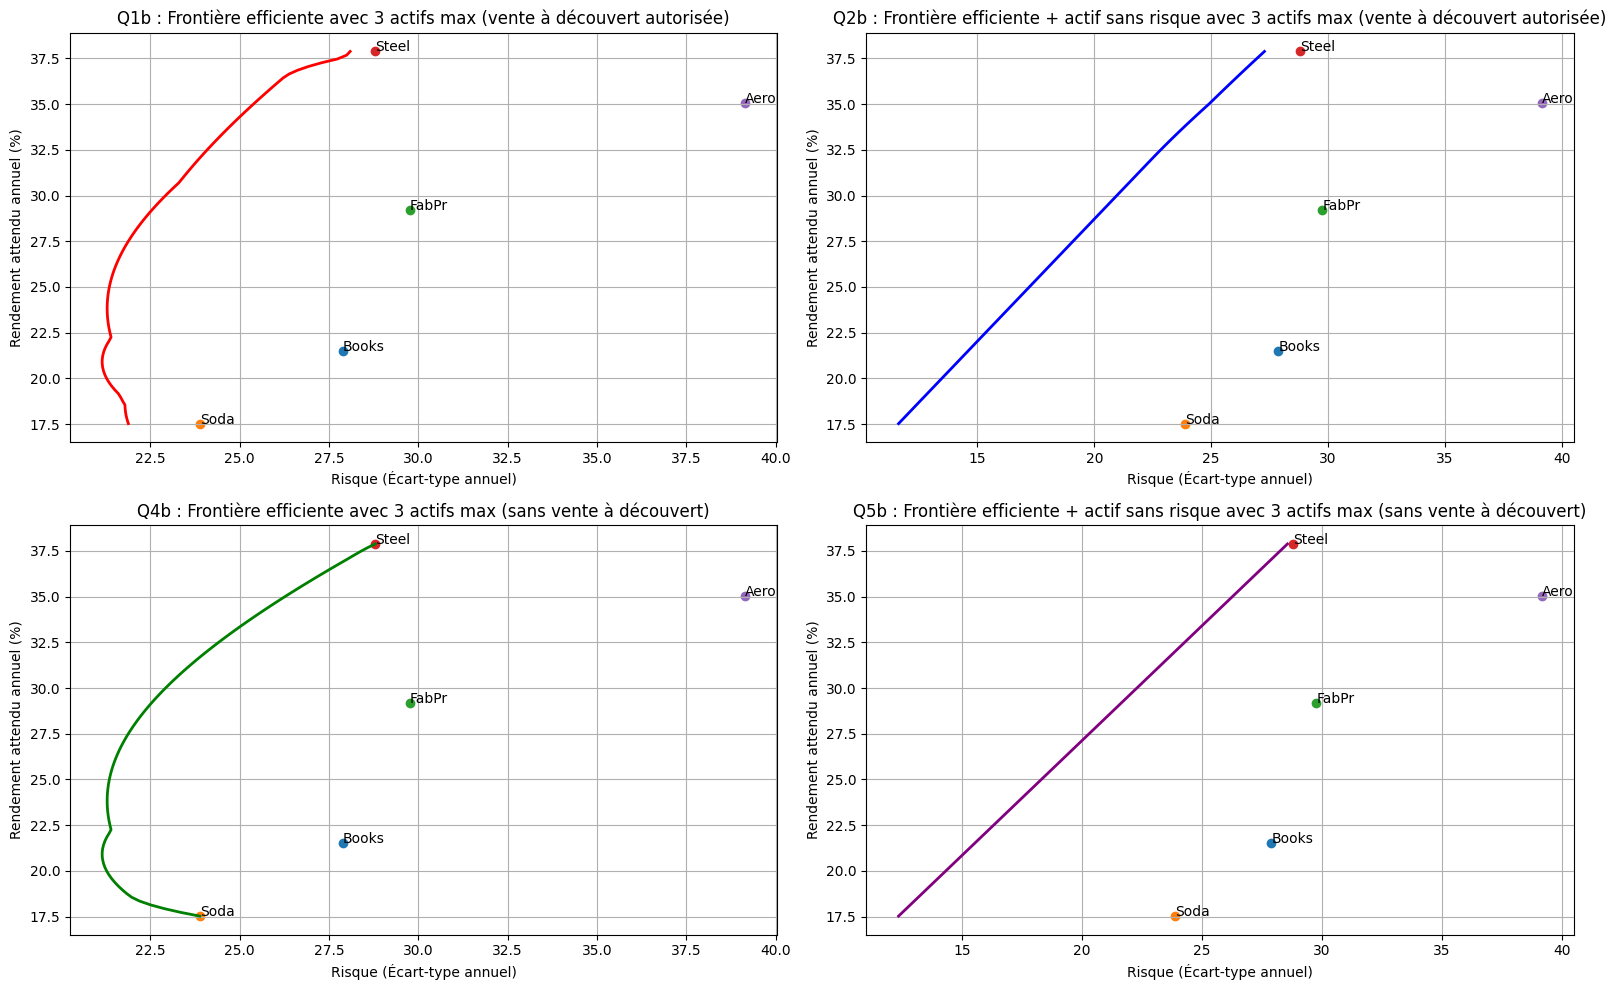


================ Q3b: Portefeuille tangent avec 3 actifs max (vente à découvert autorisée) ================
Taux sans risque R (annuel, en %): 2.000000
Somme des poids (doit être 1): 1.0000000000

Poids par industrie (w_tan_3b):
  Books: -0.308819
  Soda: 0.308819
  FabPr: 0.000000
  Steel: 1.000000
  Aero: 0.000000
Moyenne du portefeuille tangent μ_tan (%/an): 36.648763
Variance du portefeuille tangent Var_tan: 696.016171
Écart-type du portefeuille tangent σ_tan (%/an): 26.382118
Sharpe_tan = (μ_tan - R)/σ_tan: 1.313343

Vérification numérique (frontière efficiente risquée):
Sharpe maximum sur la frontière (discrétisée): 1.313636
Différence |Sharpe_max - Sharpe_tan|: 2.935554e-04

================ Q6b: Portefeuille tangent avec 3 actifs max (sans vente à découvert) ================
Taux sans risque R (annuel, en %): 2.000000
Somme des poids (doit être 1): 1.0000000000

Poids par industrie (w_q6b):
  Books: 0.000000
  Soda: 0.113960
  FabPr: 0.088072
  Steel: 0.797969
  Aero: 0.000000

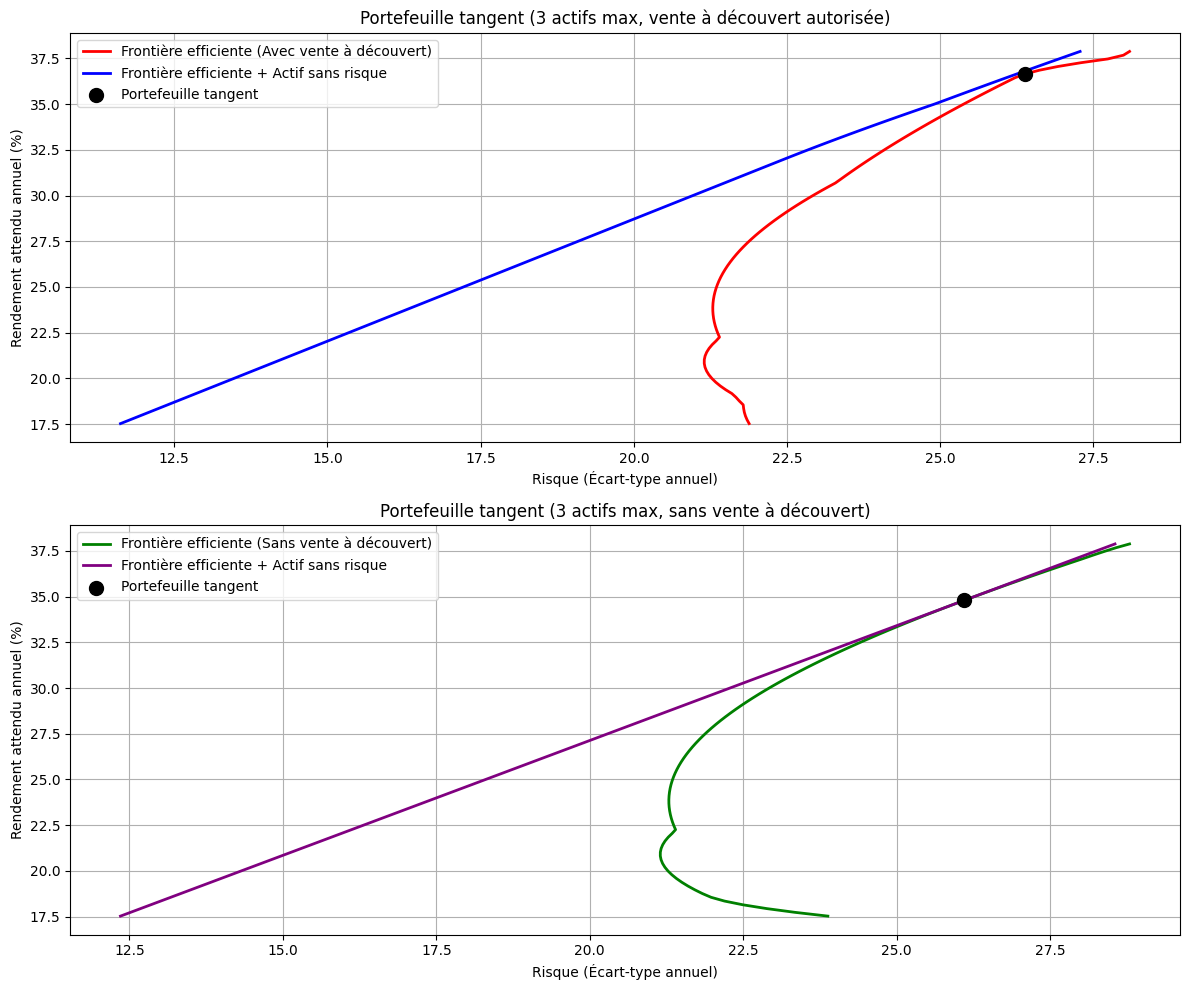

In [27]:
from partieB import *
R = 2
#we repeat question 1 to 6 with max 3 assets
weights_q1b,variances_q1b,returns_q1b,mu_q1b = efficient_frontier_asset_subset(data_last_five_years,sigma,annualize=True, short_selling=True,max_asset=3)
weights_q2b, variances_q2b, returns_q2b, mu_q2b = efficient_frontier_asset_subset(data_last_five_years,sigma,annualize=True, short_selling=True,max_asset=3, rf = R)

risky_frontier_3b = {
    'variance': np.array(variances_q1b),
    'return': np.array(returns_q1b),
    'weights': weights_q1b
}
riskless_frontier_3b = {
    'variance': np.array(variances_q2b),
    'return': np.array(returns_q2b),
    'weights': weights_q2b
}
weights_tan_3b, var_tan_3b, ret_tan_3b, sharpe_tan_3b = tangency_portfolio_heuristic(risky_frontier_3b, riskless_frontier_3b, R)



weights_q4b, variances_q4b, returns_q4b, mu_q4b = efficient_frontier_asset_subset(data_last_five_years,sigma,annualize=True, short_selling=False,max_asset=3)
weights_q5b, variances_q5b, returns_q5b, mu_q5b = efficient_frontier_asset_subset(data_last_five_years,sigma,annualize=True, short_selling=False,max_asset=3, rf = R)

risky_frontier_q6b = {
    'variance': np.array(variances_q4b),
    'return': np.array(returns_q4b),
    'weights': weights_q4b
}
riskless_frontier_q6b = {
    'variance': np.array(variances_q5b),
    'return': np.array(returns_q5b),
    'weights': weights_q5b
}
weights_q6b, var_q6b, ret_q6b, sharpe_q6b = tangency_portfolio_heuristic(risky_frontier_q6b, riskless_frontier_q6b, R)


#we plot the results in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs[0, 0].set_title("Q1b : Frontière efficiente avec 3 actifs max (vente à découvert autorisée)")
axs[0, 0].plot(np.sqrt(variances_q1b), returns_q1b, color='red', linewidth=2)
axs[0, 0].set_xlabel('Risque (Écart-type annuel)')
axs[0, 0].set_ylabel('Rendement attendu annuel (%)')
axs[0, 0].grid(True)

axs[0, 1].set_title("Q2b : Frontière efficiente + actif sans risque avec 3 actifs max (vente à découvert autorisée)")
axs[0, 1].plot(np.sqrt(variances_q2b), returns_q2b, color='blue', linewidth=2)
axs[0, 1].set_xlabel('Risque (Écart-type annuel)')
axs[0, 1].set_ylabel('Rendement attendu annuel (%)')
axs[0, 1].grid(True)

axs[1, 0].set_title("Q4b : Frontière efficiente avec 3 actifs max (sans vente à découvert)")
axs[1, 0].plot(np.sqrt(variances_q4b), returns_q4b, color='green', linewidth=2)
axs[1, 0].set_xlabel('Risque (Écart-type annuel)')
axs[1, 0].set_ylabel('Rendement attendu annuel (%)')
axs[1, 0].grid(True)

axs[1, 1].set_title("Q5b : Frontière efficiente + actif sans risque avec 3 actifs max (sans vente à découvert)")
axs[1, 1].plot(np.sqrt(variances_q5b), returns_q5b, color='purple', linewidth=2)
axs[1, 1].set_xlabel('Risque (Écart-type annuel)')
axs[1, 1].set_ylabel('Rendement attendu annuel (%)')
axs[1, 1].grid(True)

for i, industry in enumerate(industries):
    asset_sigma = np.sqrt(sigma.values[i] * 12)
    mu_asset = mu[i]
    for ax in axs.flatten():
        ax.scatter(asset_sigma[i], mu_asset)
        ax.text(asset_sigma[i], mu_asset, industry)

plt.tight_layout()
plt.show()

print("\n================ Q3b: Portefeuille tangent avec 3 actifs max (vente à découvert autorisée) ================")
print(f"Taux sans risque R (annuel, en %): {R:.6f}")
print(f"Somme des poids (doit être 1): {weights_tan_3b.sum():.10f}")
print(f"\nPoids par industrie (w_tan_3b):")
for industry, weight in weights_tan_3b.items():
    print(f"  {industry}: {weight:.6f}")
print(f"Moyenne du portefeuille tangent μ_tan (%/an): {ret_tan_3b:.6f}")
print(f"Variance du portefeuille tangent Var_tan: {var_tan_3b:.6f}")
print(f"Écart-type du portefeuille tangent σ_tan (%/an): {np.sqrt(var_tan_3b):.6f}")
print(f"Sharpe_tan = (μ_tan - R)/σ_tan: {sharpe_tan_3b:.6f}")

sharpe_max, idx_max = verify_tangency_max_sharpe(returns_q1b, variances_q1b, R=R)
print("\nVérification numérique (frontière efficiente risquée):")
print(f"Sharpe maximum sur la frontière (discrétisée): {sharpe_max:.6f}")
print(f"Différence |Sharpe_max - Sharpe_tan|: {abs(sharpe_max - sharpe_tan_3b):.6e}")



print("\n================ Q6b: Portefeuille tangent avec 3 actifs max (sans vente à découvert) ================")
print(f"Taux sans risque R (annuel, en %): {R:.6f}")
print(f"Somme des poids (doit être 1): {weights_q6b.sum():.10f}")
print(f"\nPoids par industrie (w_q6b):")
for industry, weight in weights_q6b.items():
    print(f"  {industry}: {weight:.6f}")
print(f"Moyenne du portefeuille tangent μ_tan (%/an): {ret_q6b:.6f}")
print(f"Variance du portefeuille tangent Var_tan: {var_q6b:.6f}")
print(f"Écart-type du portefeuille tangent σ_tan (%/an): {np.sqrt(var_q6b):.6f}")
print(f"Sharpe_tan = (μ_tan - R)/σ_tan: {sharpe_q6b:.6f}")


sharpe_max, idx_max = verify_tangency_max_sharpe(returns_q4b, variances_q4b, R=R)
print("\nVérification numérique (frontière efficiente risquée):")
print(f"Sharpe maximum sur la frontière (discrétisée): {sharpe_max:.6f}")
print(f"Différence |Sharpe_max - Sharpe_tan|: {abs(sharpe_max - sharpe_q6b):.6e}")

#plotting the tangency portfolios found in Q3b and Q6b on the previous frontier plots in a 2x1 grid
fig, axs = plt.subplots(2, 1, figsize=(12, 10))
axs[0].set_title("Portefeuille tangent (3 actifs max, vente à découvert autorisée)")
axs[0].plot(np.sqrt(variances_q1b), returns_q1b, color='red', linewidth=2, label='Frontière efficiente (Avec vente à découvert)')
axs[0].plot(np.sqrt(variances_q2b), returns_q2b, color='blue', linewidth=2, label='Frontière efficiente + Actif sans risque')
axs[0].scatter(np.sqrt(var_tan_3b), ret_tan_3b, color='black', s=100, zorder=5, label='Portefeuille tangent')
axs[0].set_xlabel('Risque (Écart-type annuel)')
axs[0].set_ylabel('Rendement attendu annuel (%)')
axs[0].legend()
axs[0].grid(True)

axs[1].set_title("Portefeuille tangent (3 actifs max, sans vente à découvert)")
axs[1].plot(np.sqrt(variances_q4b), returns_q4b, color='green', linewidth=2, label='Frontière efficiente (Sans vente à découvert)')
axs[1].plot(np.sqrt(variances_q5b), returns_q5b, color='purple', linewidth=2, label='Frontière efficiente + Actif sans risque')
axs[1].scatter(np.sqrt(var_q6b), ret_q6b, color='black', s=100, zorder=5, label='Portefeuille tangent')
axs[1].set_xlabel('Risque (Écart-type annuel)')
axs[1].set_ylabel('Rendement attendu annuel (%)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Question 4

In [28]:
from partieB import run_maxser_from_returns

# data = 48 industries (déjà chargé plus haut)
industry_returns = data.copy()

# garder 10 ans + conversion % en décimal
industry_returns = (industry_returns.iloc[-120:]).dropna()

w_maxser, diag = run_maxser_from_returns(industry_returns, rf=2.0, sigma_target_annual=10)

print("theta_adj =", diag["theta_adj"])
print("rc =", diag["rc"])
print("best_l1 =", diag["best_l1"])
print("Non-zero:", diag["nonzero"])
print("Scaled vol (monthly):", diag["scaled_vol_monthly"])
print("Sharpe (ann):", diag["sharpe_ann"])

# affichage des poids non nuls
w_maxser[w_maxser.abs() > 1e-6].sort_values()

theta_adj = 0.4656680076785406
rc = 6.200215496178169
best_l1 = 0.05
Non-zero: 3
Scaled vol (monthly): 2.886751345948129
Sharpe (ann): 0.8567327509338896


Aero     0.028131
Gold     0.093356
Steel    0.207965
dtype: float64